In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import h5py
import numpy as np
import cv2
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


Mounted at /content/drive


In [2]:
BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")
MODELS = os.path.join(BASE, "models")

train_h5 = h5py.File(os.path.join(PROC, "train.h5"), "r")
test_h5  = h5py.File(os.path.join(PROC, "test.h5"),  "r")

X_train_ds = train_h5["X"]
y_train_ds = train_h5["y"]
X_test_ds  = test_h5["X"]
y_test_ds  = test_h5["y"]

print("Train samples:", X_train_ds.shape[0])
print("Test samples:", X_test_ds.shape[0])


Train samples: 7177
Test samples: 1803


In [4]:
from tqdm import tqdm
import numpy as np
import h5py
import os

BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")

train_h5 = h5py.File(os.path.join(PROC, "train.h5"), "r")
X_train_ds = train_h5["X"]

total_sum = 0.0
total_sum_sq = 0.0
total_count = 0

batch_size = 1000
n = X_train_ds.shape[0]

print("Computing global mean and std in streaming mode...")

for i in tqdm(range(0, n, batch_size)):
    batch = X_train_ds[i:i+batch_size]  # HDF5 slice, not loaded fully
    total_sum += batch.sum()
    total_sum_sq += (batch**2).sum()
    total_count += np.prod(batch.shape)

mean = total_sum / total_count
var = (total_sum_sq / total_count) - (mean**2)
std = np.sqrt(var)

print("Mean:", mean)
print("Std:", std)

np.savez(os.path.join(PROC, "stats.npz"), mean=mean, std=std)
print("Saved at:", os.path.join(PROC, "stats.npz"))


Computing global mean and std in streaming mode...


100%|██████████| 8/8 [01:06<00:00,  8.31s/it]

Mean: -2.633200133717971e-06
Std: 0.9996264772469634
Saved at: /content/drive/MyDrive/morph_project/processed/stats.npz


In [5]:
stats = np.load(os.path.join(PROC, "stats.npz"))
mean = stats["mean"].item() if stats["mean"].shape == () else stats["mean"]
std  = stats["std"].item()  if stats["std"].shape  == () else stats["std"]

print("Mean:", mean)
print("Std:", std)


Mean: -2.633200133717971e-06
Std: 0.9996264772469634


In [6]:
# Multi-scale LBP settings
SCALES = [(8,1), (16,2), (24,3)]

def lbp_histogram(gray, P, R):
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, P+3),
        range=(0, P+2),
        density=True
    )
    return hist.astype(np.float32)

def lbp_features_batch(images):
    # reverse standardization back to [0..1]
    images_01 = (images * (std + 1e-7)) + mean
    images_01 = np.clip(images_01, 0, 1)
    images_u8 = (images_01 * 255.0).astype(np.uint8)

    feats = []
    for img in images_u8:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        f = []
        for (P, R) in SCALES:
            f.append(lbp_histogram(gray, P, R))
        feats.append(np.concatenate(f))
    return np.array(feats)


In [7]:
def extract_lbp_from_hdf5(X_ds, batch_size=500):
    n = X_ds.shape[0]
    X_feats = []
    for i in tqdm(range(0, n, batch_size)):
        batch = X_ds[i:i+batch_size]
        feats = lbp_features_batch(batch)
        X_feats.append(feats)
    return np.concatenate(X_feats, axis=0)

X_train_lbp = extract_lbp_from_hdf5(X_train_ds, batch_size=500)
X_test_lbp  = extract_lbp_from_hdf5(X_test_ds, batch_size=500)

y_train = np.array(y_train_ds, dtype=np.int32)
y_test  = np.array(y_test_ds, dtype=np.int32)

print("Train LBP shape:", X_train_lbp.shape)
print("Test LBP shape:", X_test_lbp.shape)


100%|██████████| 4/4 [02:15<00:00, 34.00s/it]

Train LBP shape: (7177, 54)
Test LBP shape: (1803, 54)


In [8]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train_lbp, y_train)

pred = rf.predict(X_test_lbp)
acc = accuracy_score(y_test, pred)

print("RandomForest Accuracy:", acc)


RandomForest Accuracy: 0.8252911813643927


In [9]:
print(classification_report(y_test, pred, target_names=["Au","Tp"]))
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

          Au       0.83      0.99      0.90      1489
          Tp       0.48      0.05      0.09       314

    accuracy                           0.83      1803
   macro avg       0.66      0.52      0.50      1803
weighted avg       0.77      0.83      0.76      1803

[[1473   16]
 [ 299   15]]


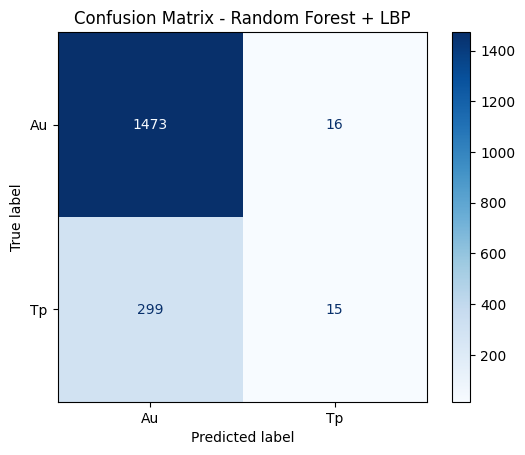

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Au", "Tp"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest + LBP")
plt.show()


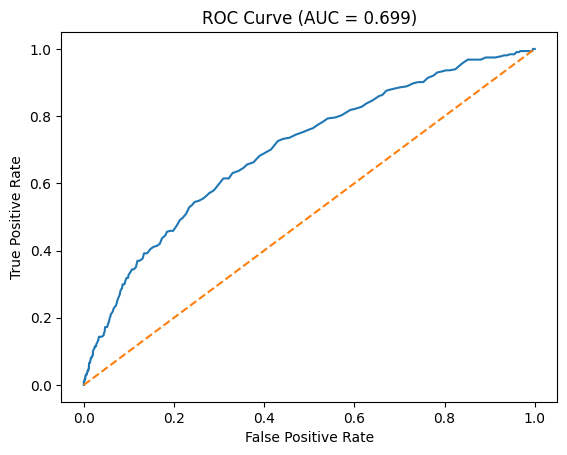

In [11]:
from sklearn.metrics import roc_curve, auc

probs = rf.predict_proba(X_test_lbp)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {round(auc_score,3)})")
plt.show()


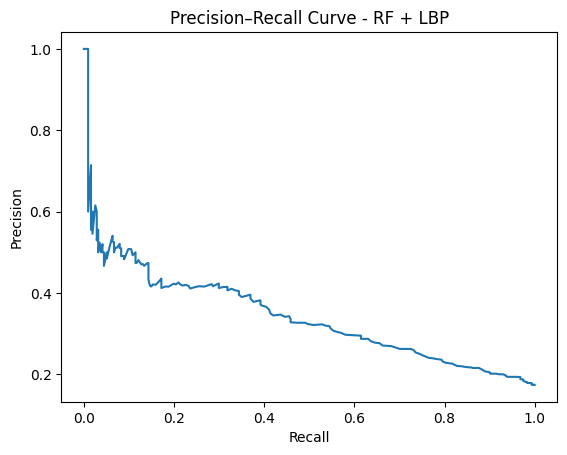

In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, thr = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - RF + LBP")
plt.show()


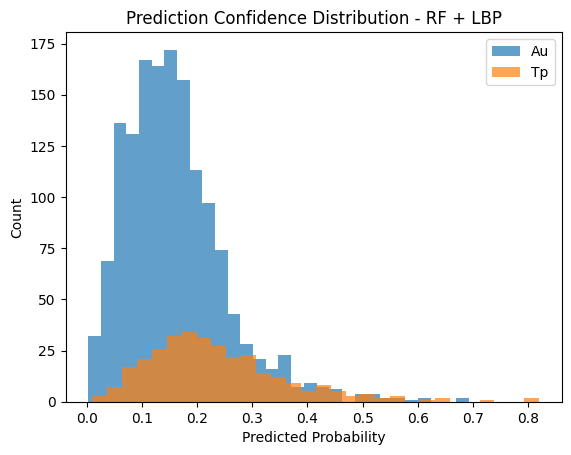

In [13]:
plt.hist(probs[y_test==0], bins=30, alpha=0.7, label="Au")
plt.hist(probs[y_test==1], bins=30, alpha=0.7, label="Tp")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution - RF + LBP")
plt.legend()
plt.show()


In [14]:
os.makedirs(MODELS, exist_ok=True)
model_path = os.path.join(MODELS, "rf_lbp_model.pkl")
joblib.dump(rf, model_path)
print("Saved model:", model_path)


Saved model: /content/drive/MyDrive/morph_project/models/rf_lbp_model.pkl


In [23]:
# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Imports
import os
import cv2
import joblib
import numpy as np
from skimage.feature import local_binary_pattern
from google.colab import files

# 3) Paths for model + statistics
BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")
MODEL_PATH = os.path.join(BASE, "models", "rf_lbp_model.pkl")

# 4) Load mean and std
stats = np.load(os.path.join(PROC, "stats.npz"))
mean = stats["mean"].item() if stats["mean"].shape == () else stats["mean"]
std  = stats["std"].item() if stats["std"].shape  == () else stats["std"]

# 5) LBP feature extraction (same as during training)
SCALES = [(8,1), (16,2), (24,3)]

def lbp_histogram(gray, P, R):
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, P+3),
        range=(0, P+2),
        density=True
    )
    return hist.astype(np.float32)

def lbp_features_batch(images):
    images_01 = (images * (std + 1e-7)) + mean
    images_01 = np.clip(images_01, 0, 1)
    images_u8 = (images_01 * 255.0).astype(np.uint8)

    feats = []
    for img in images_u8:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        f = []
        for (P, R) in SCALES:
            f.append(lbp_histogram(gray, P, R))
        feats.append(np.concatenate(f))
    return np.array(feats)

# 6) Preprocess + predict for a single image
def predict_uploaded_image():
    # Upload image from PC
    uploaded = files.upload()
    for fname in uploaded.keys():
        print("Uploaded:", fname)

        img_bgr = cv2.imread(fname)
        if img_bgr is None:
            print("Could not read image.")
            continue

        # Preprocessing (same as training)
        img = cv2.resize(img_bgr, (224,224))
        img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

        img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
        img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

        img = img.astype(np.float32) / 255.0
        img = (img - mean) / (std + 1e-7)

        # LBP features
        feats = lbp_features_batch(img[np.newaxis,...])

        # Load model
        model = joblib.load(MODEL_PATH)

        pred = model.predict(feats)[0]
        prob = model.predict_proba(feats).max()

        classes = ["Au", "Tp"]
        print("Prediction:", classes[pred])
        print("Confidence:", round(prob*100, 2), "%")

# 7) Run prediction
predict_uploaded_image()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving img3.png to img3.png
Uploaded: img3.png
Prediction: Au
Confidence: 79.75 %
